In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
df = pd.read_csv("CSV.csv")
df = df.select_dtypes(include=np.number)
df = df.dropna()
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
class LogisticRegressionGD:
    def __init__(self, lr=0.01, iterations=3000):
        self.lr = lr
        self.iterations = iterations
        self.W = None
        self.b = None
        self.costs = []
    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))
    def fit(self, X, y):
        n_features = X.shape[0]
        m = X.shape[1]
        self.W = np.zeros((1, n_features))
        self.b = 0
        self.costs = []
        for i in range(self.iterations):
            Z = np.dot(self.W, X) + self.b
            A = self.sigmoid(Z)
            cost = -(1/m) * np.sum(y * np.log(A + 1e-8) + (1-y) * np.log(1-A + 1e-8))
            dW = (1/m) * np.dot((A - y), X.T)
            db = (1/m) * np.sum(A - y)
            self.W -= self.lr * dW
            self.b -= self.lr * db
            if i % 100 == 0:
                self.costs.append(cost)
                if i % 500 == 0:
                    print(f"Iteration {i} | Cost: {cost:.6f}")
    def predict(self, X, threshold=1.0):
        Z = np.dot(self.W, X) + self.b
        probabilities = self.sigmoid(Z)
        return (probabilities >= threshold).astype(int)
    def get_accuracy(self, y_true, y_pred):
        return (np.mean(y_pred == y_true)) * 100


Iteration 0 | Cost: 0.693147
Iteration 500 | Cost: 0.368411
Iteration 1000 | Cost: 0.313476
Iteration 1500 | Cost: 0.294548
Iteration 2000 | Cost: 0.285730
Iteration 2500 | Cost: 0.280903
------------------------------
Standard Accuracy (0.5): 85.94%
Tolerant Accuracy (0.4): 85.00%


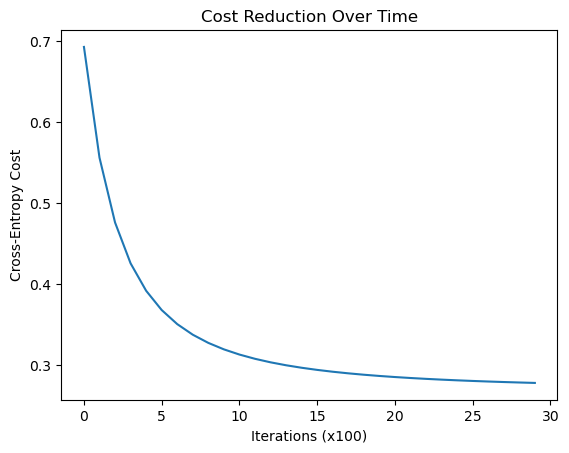

In [ ]:
# --- 1. Data Loading and Preprocessing ---
df = pd.read_csv("CSV.csv")
df = df.select_dtypes(include=np.number).dropna()

# Binary Target: 1 for High failed (>= 7), 0 for Others
df["failed"] = (df["failed"] >= 7).astype(int)

X = df.drop("failed", axis=1).values
y = df["failed"].values.reshape(1, -1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y.T, test_size=0.2, random_state=42, shuffle=True
)

# Feature Scaling (Crucial for Logistic Regression Convergence)
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
X_train = ((X_train - mean) / std).T
X_test = ((X_test - mean) / std).T
y_train, y_test = y_train.T, y_test.T

# --- 2. Train the Model ---
model = LogisticRegressionGD(lr=0.01, iterations=3000)
model.fit(X_train, y_train)

# --- 3. Prediction with Tolerance ---
# standard: 0.5 threshold
y_pred_std = model.predict(X_test, threshold=0.5)
acc_std = model.get_accuracy(y_test, y_pred_std)


print("-" * 30)
print(f"Standard Accuracy (0.5): {acc_std:.2f}%")

# Plot Cost Reduction
plt.plot(model.costs)
plt.title("Cost Reduction Over Time")
plt.xlabel("Iterations (x100)")
plt.ylabel("Cross-Entropy Cost")
plt.show()

In [ ]:
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def train_binary(X, Y, lr=0.01, iterations=2000):

    W = np.zeros((1, X.shape[0]))
    b = 0

    for i in range(iterations):

        Z = np.dot(W, X) + b
        A = sigmoid(Z)

        dW = (1/X.shape[1]) * np.dot((A - Y), X.T)
        db = (1/X.shape[1]) * np.sum(A - Y)

        W -= lr * dW
        b -= lr * db

    return W, b

models = []

for c in range(3):
    Y_binary = (y_train == c).astype(int).reshape(1, -1)
    W, b = train_binary(X_train, Y_binary)
    models.append((W, b))

def predict_ovr(models, X):

    probs = []

    for W, b in models:
        prob = sigmoid(np.dot(W, X) + b)
        probs.append(prob)

    probs = np.vstack(probs)
    return np.argmax(probs, axis=0)


y_pred_ovr = predict_ovr(models, X_test)

ovr_accuracy = np.mean(y_pred_ovr == y_test) * 100
print("OvR Accuracy:", ovr_accuracy, "%")

OvR Accuracy: 86.25 %
